In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity

In [5]:
df = pd.read_csv("imputed_data_Economic.csv")

# Interpolate missing numeric values linearly
df = df.interpolate(method='linear', limit_direction='forward', axis=0)

# Select only numeric columns for FA
df_numeric = df.drop(columns=['Country', 'Year'])

# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

/var/folders/8j/s4crl2511pdg9vg6q8sk1qzw0000gn/T/ipykernel_2909/3087088480.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear', limit_direction='forward', axis=0)


In [6]:
kmo_all, kmo_model = calculate_kmo(df_scaled)
print("KMO Test:", kmo_model) 

chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)
print("Bartlett’s Test Chi-square:", chi_square_value, "p-value:", p_value)

KMO Test: 0.7329814748651803
Bartlett’s Test Chi-square: 29881.277322761165 p-value: 0.0


Eigenvalues: [2.68637465 1.09974137 1.00424088 0.90043577 0.19265186 0.11655547]


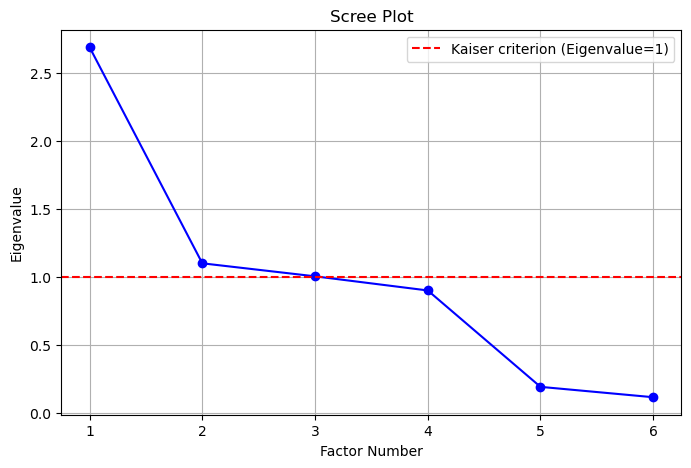

In [7]:
corr_matrix = np.corrcoef(df_scaled.T)
eigenvalues, _ = np.linalg.eig(corr_matrix)
print("Eigenvalues:", eigenvalues)

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='blue')
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser criterion (Eigenvalue=1)')
plt.title('Scree Plot')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, len(eigenvalues)+1))
plt.legend()
plt.grid(True)
plt.show()

In [8]:
n_factors = np.sum(eigenvalues > 1)  # Kaiser criterion

In [9]:
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(df_scaled)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,n_factors,np.int64(3)
,rotation,'varimax'
,method,'minres'
,use_smc,True
,is_corr_matrix,False
,bounds,"(0.005, ...)"
,impute,'median'
,svd_method,'randomized'
,rotation_kwargs,{}


In [10]:
loadings = pd.DataFrame(fa.loadings_, index=df_numeric.columns, columns=[f'Factor{i+1}' for i in range(n_factors)])
print("\nFactor Loadings:\n", loadings)

# Variance 
variance = pd.DataFrame(fa.get_factor_variance(), 
                        index=['Variance', 'Proportional Variance', 'Cumulative Variance'], 
                        columns=[f'Factor{i+1}' for i in range(n_factors)])
print("\nVariance Explained:\n", variance)


Factor Loadings:
                                Factor1   Factor2   Factor3
Inflation_Rate               -0.027361  0.994209  0.076258
GDP_Per_Capita                0.962161  0.001705  0.032288
GDP_Growth_Rate              -0.054126 -0.048189 -0.122706
Unemployment_Rate            -0.039219 -0.054578  0.716476
Cost of Living Index          0.894722  0.028010  0.036586
Local Purchasing Power Index  0.884041 -0.026711  0.195789

Variance Explained:
                         Factor1   Factor2   Factor3
Variance               2.513026  0.995253  0.574924
Proportional Variance  0.418838  0.165876  0.095821
Cumulative Variance    0.418838  0.584713  0.680534
